# FFT-Based PEEC — Method 3+4 (Tooth-Tip Source + Region Weighting)

**Goal:** Reproduce FEA's C1/C6 eddy current gradient using asymmetric PEEC source weighting.

**Pipeline:**
1. Phase A: Setup (Imports → TXT parsing → Mesh extraction)
2. Phase B: PEEC Model (Grid → Z matrix → Slot filter → Boundary)
3. Phase C: FEA Reference (FullFEA → Je extraction)
4. Phase D: FFT-PEEC + Method 3+4 (Harmonic solve → Region weighting)

**Motor:** 8P/48S IPM Hairpin, 6 layers/slot, f_e=1067Hz at 16000RPM  
**Reference:** Morisco 2019 (PEEC-FFT), Dowell/Ahagon (proximity effect)

## Phase A: Environment Setup

In [1]:
# ═══ [A1] Imports & Path Setup ═══
import pathlib, sys, importlib, time, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, solve as np_solve
from numpy.fft import rfft
from matplotlib.path import Path as MplPath
from matplotlib.patches import Rectangle, Polygon as MplPolygon
from matplotlib.colors import Normalize
from matplotlib.tri import Triangulation
import matplotlib.cm as cm

# Repo root
repo_root = pathlib.Path.cwd().resolve()
while not (repo_root / "tools").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# HYB package
acloss_root = repo_root / "tools" / "loss" / "ACLOSS"
if str(acloss_root) not in sys.path:
    sys.path.insert(0, str(acloss_root))

# HYB modules
from HYB.filament import build_filament_grid, skin_depth, FilamentGrid
from HYB.impedance import build_impedance_matrix, build_connectivity_matrix
from HYB.solver import solve_peec, PEECResult
from HYB.loss import calculate_losses, LossResult
from HYB.magnetization import (
    extract_magnetization_currents, extract_magnetization_fundamental,
    MagnetizationCurrent, precompute_boundary_edges, BoundaryEdgeCache
)
from HYB.morisco_pipeline import MoriscoPipeline, MoriscoConfig

# pyMCAD
from tools.motorCAD.pyMCAD import MagneticRegions, get_magnetic_timeseries_from_file

MU_0 = 4 * np.pi * 1e-7
print("Imports OK")

Imports OK


In [2]:
# ═══ [A2] Motor-CAD Connection + Constants ═══
try:
    import ansys.motorcad.core as pymotorcad
    mcad = pymotorcad.MotorCAD(open_new_instance=False)
    COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))
    COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
    ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
    n_parallel = int(mcad.get_variable("ParallelPaths"))
    n_turns = int(mcad.get_variable("WindingLayers"))
    N_POLES = int(mcad.get_variable("Pole_Number"))
    stator_bore_mm = float(mcad.get_variable("Stator_Bore"))
    slot_depth_mm = float(mcad.get_variable("Slot_Depth"))
    tooth_tip_depth_mm = float(mcad.get_variable("Tooth_Tip_Depth"))
    MCAD_AVAILABLE = True
    print(f"Motor-CAD connected")
    print(f"  Conductor: {COND_WIDTH_MM:.2f} x {COND_HEIGHT_MM:.2f} mm")
    print(f"  Active length: {ACTIVE_LENGTH_MM:.1f} mm, Poles: {N_POLES}")
    print(f"  Stator bore: {stator_bore_mm:.1f} mm, Slot depth: {slot_depth_mm:.1f} mm")
except Exception as e:
    print(f"Motor-CAD not available: {e}")
    MCAD_AVAILABLE = False
    # e10 defaults
    COND_WIDTH_MM = 2.80; COND_HEIGHT_MM = 2.50; ACTIVE_LENGTH_MM = 150.0
    N_POLES = 8; n_turns = 6; n_parallel = 1
    stator_bore_mm = 200.0; slot_depth_mm = 20.0; tooth_tip_depth_mm = 1.0

# SI conversion
SIGMA_CU = 5.8e7
h_m = COND_HEIGHT_MM * 1e-3   # radial height [m]
b_m = COND_WIDTH_MM * 1e-3    # tangential width [m]
L_a = ACTIVE_LENGTH_MM * 1e-3 # active length [m]
POLE_PAIRS = N_POLES // 2
N_COND_PER_SLOT = n_turns
I_rms = 460.0
N_SLOTS = 48

# Slot geometry
R_slot_inner_mm = stator_bore_mm / 2 + tooth_tip_depth_mm
R_slot_outer_mm = (stator_bore_mm + 2 * slot_depth_mm) / 2
print(f"  R_slot: [{R_slot_inner_mm:.1f}, {R_slot_outer_mm:.1f}] mm")

Motor-CAD connected
  Conductor: 5.57 x 2.53 mm
  Active length: 150.0 mm, Poles: 8
  Stator bore: 213.8 mm, Slot depth: 20.7 mm
  R_slot: [108.4, 127.7] mm


In [3]:
# ═══ [A3] FEA TXT File Discovery + Parsing ═══
export_root = Path(r"D:\KangDH\Thesis\e10\SLFEA\ACLossCalcExport")

found_txts = {}
if export_root.exists():
    for model_dir in export_root.iterdir():
        if not model_dir.is_dir(): continue
        for mode_dir in model_dir.iterdir():
            if not mode_dir.is_dir(): continue
            for txt in sorted(mode_dir.glob("*.txt")):
                key = f"{model_dir.name}/{mode_dir.name}/{txt.stem}"
                found_txts[key] = txt

print(f"Found {len(found_txts)} TXT files")

# Target selection
TARGET_MODEL = "halfsc"
TARGET_MODE = "hybrid"
TARGET_SPEED = 16000

target_key = None
for k in found_txts:
    if TARGET_MODEL in k and TARGET_MODE in k and str(TARGET_SPEED) in k:
        target_key = k
        break

assert target_key is not None, f"File not found: {TARGET_MODEL}/{TARGET_MODE}/{TARGET_SPEED}"
test_path = found_txts[target_key]
print(f"Parsing: {target_key}")

ts_morisco = get_magnetic_timeseries_from_file(str(test_path))
n_steps = len(ts_morisco.steps)
freq = POLE_PAIRS * TARGET_SPEED / 60.0
omega = 2 * np.pi * freq

print(f"  Steps: {n_steps}, f_e={freq:.0f} Hz, delta={skin_depth(freq, SIGMA_CU)*1e3:.3f} mm")

Found 16 TXT files
Parsing: halfsc/hybrid/hybrid_halfsc_16000RPM
  Steps: 128, f_e=1067 Hz, delta=1.431 mm


In [4]:
# ═══ [A4] DXF Polygons + Slot Classification + Local Coords ═══
mr0 = ts_morisco.by_step[ts_morisco.steps[0]]

# (A) DXF conductor polygons
pkl_path = Path(r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\conductor_polygons_dxf.pkl")
with open(pkl_path, "rb") as f:
    dxf_data = pickle.load(f)

cond_polys_all = dxf_data["all_conductor_polygons_6slots"]
n_polys_total = len(cond_polys_all)
poly_centroids_mm = np.array([cp["vertices"].mean(axis=0) for cp in cond_polys_all])
poly_areas_mm2_all = np.array([cp.get("area_mm2", 0) for cp in cond_polys_all])
all_cond_paths = [MplPath(cp["vertices"]) for cp in cond_polys_all]

# (B) Slot classification (angular clustering)
slot_pitch_rad = 2 * np.pi / N_SLOTS
poly_angles_norm = np.arctan2(poly_centroids_mm[:, 1], poly_centroids_mm[:, 0]) % (2 * np.pi)
sorted_poly_idx = np.argsort(poly_angles_norm)
sorted_angles = poly_angles_norm[sorted_poly_idx]

slot_groups = {}
current_slot = 0
current_group = [sorted_poly_idx[0]]
for i in range(1, n_polys_total):
    idx = sorted_poly_idx[i]
    if sorted_angles[i] - sorted_angles[i-1] > slot_pitch_rad * 0.4:
        slot_groups[current_slot] = current_group
        current_slot += 1
        current_group = [idx]
    else:
        current_group.append(idx)
slot_groups[current_slot] = current_group

# Radial sort within each slot
slot_groups_sorted = {}
for sid, poly_indices in slot_groups.items():
    radii = np.linalg.norm(poly_centroids_mm[poly_indices], axis=1)
    slot_groups_sorted[sid] = [poly_indices[j] for j in np.argsort(radii)]

# (C) Target slot selection
TARGET_SLOT = 0
slot_poly_idx = np.array(slot_groups_sorted[TARGET_SLOT])
slot_polys = [cond_polys_all[i] for i in slot_poly_idx]
cond_centers = poly_centroids_mm[slot_poly_idx] * 1e-3  # [m]
n_cond = len(cond_centers)

# (D) Slot-local coordinate transform
slot_center_global = cond_centers.mean(axis=0)
slot_angle_rad = np.arctan2(slot_center_global[1], slot_center_global[0])
cond_centers_local = cond_centers - slot_center_global
cos_rot = np.cos(-slot_angle_rad); sin_rot = np.sin(-slot_angle_rad)
x_rot = cond_centers_local[:, 0] * cos_rot - cond_centers_local[:, 1] * sin_rot
y_rot = cond_centers_local[:, 0] * sin_rot + cond_centers_local[:, 1] * cos_rot
cond_local_rotated = np.column_stack([y_rot, x_rot])  # [tang, rad]

print(f"Slots: {len(slot_groups)}, Target slot #{TARGET_SLOT}: {n_cond} conductors")
print(f"  Slot center: ({slot_center_global[0]*1e3:.2f}, {slot_center_global[1]*1e3:.2f}) mm")
print(f"  Radial span: {(cond_local_rotated[:,1].max()-cond_local_rotated[:,1].min())*1e3:.2f} mm")

Slots: 6, Target slot #0: 6 conductors
  Slot center: (88.76, -77.84) mm
  Radial span: 15.27 mm


In [5]:
# ═══ [A5] FEA Mesh + B/H Timeseries Extraction ═══
t0 = time.perf_counter()

# Node coordinates (mm -> m)
node_ids_sorted = sorted(mr0.node_xy.keys())
node_id_to_idx = {nid: i for i, nid in enumerate(node_ids_sorted)}
node_xy_arr = np.array([mr0.node_xy[nid] for nid in node_ids_sorted]) * 1e-3
n_nodes = len(node_xy_arr)

# Element connectivity
elements = []
for reg in mr0._regions:
    for el in reg.elements:
        n1 = node_id_to_idx.get(el.node_1, -1)
        n2 = node_id_to_idx.get(el.node_2, -1)
        n3 = node_id_to_idx.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            elements.append((n1, n2, n3))
triangles_arr = np.array(elements, dtype=int)
n_elem_total = len(triangles_arr)

# Iron mask & mur
iron_mask_arr = np.zeros(n_elem_total, dtype=bool)
mur_arr = np.ones(n_elem_total)
elem_idx = 0
for reg in mr0._regions:
    for el in reg.elements:
        n1 = node_id_to_idx.get(el.node_1, -1)
        n2 = node_id_to_idx.get(el.node_2, -1)
        n3 = node_id_to_idx.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            el_mur = getattr(el, 'mur', 1.0) or 1.0
            if el_mur > 1.5:
                iron_mask_arr[elem_idx] = True
                mur_arr[elem_idx] = el_mur
            elem_idx += 1

# DXF copper mask
elem_centroids_mm = node_xy_arr[triangles_arr].mean(axis=1) * 1e3
is_copper_all = np.zeros(n_elem_total, dtype=bool)
for path in all_cond_paths:
    is_copper_all |= path.contains_points(elem_centroids_mm)

# B/H timeseries
bx_ts_all = np.zeros((n_steps, n_elem_total))
by_ts_all = np.zeros((n_steps, n_elem_total))
hx_ts_all = np.zeros((n_steps, n_elem_total))
hy_ts_all = np.zeros((n_steps, n_elem_total))

for si, step_key in enumerate(ts_morisco.steps):
    mr_step = ts_morisco.by_step[step_key]
    ei = 0
    for reg in mr_step._regions:
        for el in reg.elements:
            n1 = node_id_to_idx.get(el.node_1, -1)
            n2 = node_id_to_idx.get(el.node_2, -1)
            n3 = node_id_to_idx.get(el.node_3, -1)
            if n1 >= 0 and n2 >= 0 and n3 >= 0:
                bx_ts_all[si, ei] = getattr(el, 'bx', 0) or 0
                by_ts_all[si, ei] = getattr(el, 'by', 0) or 0
                hx_ts_all[si, ei] = getattr(el, 'hx', 0) or 0
                hy_ts_all[si, ei] = getattr(el, 'hy', 0) or 0
                ei += 1

print(f"Mesh: {n_nodes} nodes, {n_elem_total} elements")
print(f"  Iron: {iron_mask_arr.sum()}, Copper: {is_copper_all.sum()}")
print(f"  B/H timeseries: ({n_steps} x {n_elem_total}), {time.perf_counter()-t0:.1f}s")

Mesh: 9623 nodes, 18704 elements
  Iron: 10375, Copper: 1014
  B/H timeseries: (128 x 18704), 4.0s


## Phase B: PEEC Model Construction

In [7]:
# ═══ [B1] MoriscoPipeline + Filament Grid + Impedance Matrix ═══
pipe = MoriscoPipeline(
    cond_width=b_m, cond_height=h_m, stack_length=L_a,
    sigma_copper=SIGMA_CU, n_poles=N_POLES,
    subdivision_ratio=0.15, dirichlet_radius=L_a,
)
config = pipe.config

# Separate axial length and slot boundary radius.
L_stack = L_a
R_boundary = R_slot_outer_mm * 1e-3 + 0.5e-3

grid_local = build_filament_grid(
    conductor_centers=cond_local_rotated,
    cond_width=config.cond_width, cond_height=config.cond_height,
    length=L_stack, frequency=freq, sigma=SIGMA_CU,
    subdivision_ratio=config.subdivision_ratio,
)

t0 = time.perf_counter()
Z = build_impedance_matrix(grid_local, freq, SIGMA_CU, slot_boundary_radius=R_boundary)
C = build_connectivity_matrix(grid_local)
Z_inv = np.linalg.inv(Z)
ZiC = Z_inv @ C
CZiC = C.T @ ZiC

# Imposed current
I_cond_val = I_rms * np.sqrt(2)
I_test = np.zeros(n_cond)
I_test[0] = I_cond_val
i_imposed = ZiC @ np_solve(CZiC, I_test)

# Derived parameters
n_fil_total = grid_local.n_total
n_fil_per = grid_local.n_filaments_per_cond
nx, ny = grid_local.nx, grid_local.ny
R_matrix = np.real(Z)
L_matrix = np.imag(Z) / omega
R_fil = grid_local.length / (SIGMA_CU * grid_local.area_fil)
A_cond_area = config.cond_width * config.cond_height
R_dc = grid_local.length / (SIGMA_CU * A_cond_area)
P_dc = 0.5 * R_dc * np.sum(np.abs(I_test)**2)

print(f"Grid: {nx}x{ny} = {n_fil_per}/cond, total {n_fil_total} filaments")
print(f"Boundary radius: {R_boundary*1e3:.1f} mm, Stack length: {L_stack*1e3:.1f} mm")
print(f"Z matrix: {Z.shape}, built in {time.perf_counter()-t0:.2f}s")
print(f"R_fil={R_fil*1e3:.3f} mOhm, P_dc={P_dc:.2f} W")

Grid: 26x12 = 312/cond, total 1872 filaments
Boundary radius: 128.2 mm, Stack length: 150.0 mm
Z matrix: (1872, 1872), built in 0.52s
R_fil=57.323 mOhm, P_dc=38.88 W


In [8]:
# ═══ [B2] Slot Filter Functions + Geometry ═══
# Slot boundary radii
slot_r_min_m = R_slot_inner_mm * 1e-3 - 0.5e-3
slot_r_max_m = R_boundary

# Angular sector
cond_angles = np.arctan2(cond_centers[:, 1], cond_centers[:, 0])
slot_angle_center = np.mean(cond_angles)
slot_angle_span = np.radians(360.0 / N_SLOTS)

# Slot local half-dimensions
slot_local_half_tang = slot_angle_span * (stator_bore_mm/2 + slot_depth_mm/2) * 1e-3 / 2
slot_local_half_rad = slot_depth_mm * 1e-3 / 2


def filter_slot_wall(mag, slot_r_min, slot_r_max, angle_center, angle_span):
    """Filter magnetization sources within slot wall region."""
    r = np.linalg.norm(mag.positions, axis=1)
    a = np.arctan2(mag.positions[:, 1], mag.positions[:, 0])
    r_mask = (r >= slot_r_min) & (r <= slot_r_max)
    a_diff = np.abs(a - angle_center)
    a_diff = np.minimum(a_diff, 2*np.pi - a_diff)
    a_mask = a_diff < (angle_span / 2)
    return r_mask & a_mask


def to_slot_local(positions_global, center, rotation_angle):
    """Global coords -> slot-local (col0=tang, col1=rad)."""
    local = positions_global - center
    c, s = np.cos(-rotation_angle), np.sin(-rotation_angle)
    x_rot = local[:, 0] * c - local[:, 1] * s
    y_rot = local[:, 0] * s + local[:, 1] * c
    return np.column_stack([y_rot, x_rot])  # [tang, rad]


print(f"Slot filter: R=[{slot_r_min_m*1e3:.1f}, {slot_r_max_m*1e3:.1f}] mm")
print(f"  angle_center={np.degrees(slot_angle_center):.2f} deg")
print(f"  half_tang={slot_local_half_tang*1e3:.2f} mm, half_rad={slot_local_half_rad*1e3:.2f} mm")

Slot filter: R=[107.9, 128.2] mm
  angle_center=-41.25 deg
  half_tang=7.68 mm, half_rad=10.37 mm


In [9]:
# ═══ [B3] Boundary Cache + Reference Magnetization ═══
boundary_cache = precompute_boundary_edges(node_xy_arr, triangles_arr, iron_mask_arr)
print(f"boundary_cache: {len(boundary_cache.edge_midpoints)} edges")

# Reference magnetization (step 0)
mag_ref = extract_magnetization_currents(
    node_xy=node_xy_arr, triangles=triangles_arr,
    bx=bx_ts_all[0], by=by_ts_all[0],
    hx=hx_ts_all[0], hy=hy_ts_all[0],
    mur=mur_arr, iron_mask=iron_mask_arr,
    axial_length=L_a, boundary_cache=boundary_cache,
)

mask_fixed = filter_slot_wall(mag_ref, slot_r_min_m, slot_r_max_m,
                              slot_angle_center, slot_angle_span)
n_mag_filtered = mask_fixed.sum()
print(f"  Slot-wall sources: {n_mag_filtered} edges")

boundary_cache: 1529 edges
  Slot-wall sources: 100 edges


## Phase C: FEA Reference (FullFEA Je)

In [10]:
# ═══ [C1] FullFEA TXT Loading + Mesh + Je Extraction ═══
# Find FullFEA file
fullfea_key = None
for k in found_txts:
    if TARGET_MODEL in k and "fullfea" in k and str(TARGET_SPEED) in k:
        fullfea_key = k
        break

assert fullfea_key is not None, f"FullFEA file not found for {TARGET_MODEL}/{TARGET_SPEED}RPM"
fullfea_path = found_txts[fullfea_key]
print(f"Parsing FullFEA: {fullfea_key} ({fullfea_path.stat().st_size/1e6:.0f} MB)...")

t0 = time.perf_counter()
ts_fullfea = get_magnetic_timeseries_from_file(str(fullfea_path))
n_steps_ff = len(ts_fullfea.steps)
print(f"  Parsed: {n_steps_ff} steps, {time.perf_counter()-t0:.1f}s")

# FullFEA mesh (from step 0)
mr0_ff = ts_fullfea.by_step[ts_fullfea.steps[0]]
node_ids_ff = sorted(mr0_ff.node_xy.keys())
node_id_to_idx_ff = {nid: i for i, nid in enumerate(node_ids_ff)}
node_xy_ff = np.array([mr0_ff.node_xy[nid] for nid in node_ids_ff]) * 1e-3  # [m]

elements_ff = []
for reg in mr0_ff._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            elements_ff.append((n1, n2, n3))
triangles_ff = np.array(elements_ff, dtype=int)
n_elem_ff = len(triangles_ff)

# Copper mask for FullFEA mesh
elem_centroids_ff_mm = node_xy_ff[triangles_ff].mean(axis=1) * 1e3
is_copper_ff = np.zeros(n_elem_ff, dtype=bool)
for path in all_cond_paths:
    is_copper_ff |= path.contains_points(elem_centroids_ff_mm)

# Slot Cu mask
cu_cx_ff = elem_centroids_ff_mm[is_copper_ff, 0]
cu_cy_ff = elem_centroids_ff_mm[is_copper_ff, 1]
cu_angle_ff = np.arctan2(cu_cy_ff, cu_cx_ff)
cu_a_diff_ff = np.abs(cu_angle_ff - slot_angle_center)
cu_a_diff_ff = np.minimum(cu_a_diff_ff, 2*np.pi - cu_a_diff_ff)
slot_cu_mask_ff = cu_a_diff_ff < slot_angle_span * 0.8

cx_slot_mm = cu_cx_ff[slot_cu_mask_ff]
cy_slot_mm = cu_cy_ff[slot_cu_mask_ff]

print(f"  FullFEA mesh: {n_elem_ff} elements, Cu: {is_copper_ff.sum()}, Slot Cu: {slot_cu_mask_ff.sum()}")

Parsing FullFEA: halfsc/fullfea/fullfea_halfsc_16000RPM (495 MB)...
  Parsed: 128 steps, 22.6s
  FullFEA mesh: 21272 elements, Cu: 2304, Slot Cu: 384


In [18]:
# ═══ [C2] Find Best Step + Extract Je ═══
# Triangle-to-index lookup: element를 (n1,n2,n3)으로 식별하여
# step 0 mesh 인덱스에 정확히 매핑 (step간 region 순회 순서가 다를 수 있음)
_tri_to_idx = {}
for _i, (_n1, _n2, _n3) in enumerate(triangles_ff):
    _tri_to_idx[(_n1, _n2, _n3)] = _i
print(f"  tri_to_idx lookup: {len(_tri_to_idx)} entries")

# Find step where all conductors have J>0 and Je is significant
target_step_idx = None
for try_idx in range(n_steps_ff//2, n_steps_ff):
    _mr = ts_fullfea.by_step[ts_fullfea.steps[try_idx]]
    _je = np.zeros(n_elem_ff)
    for reg in _mr._regions:
        for el in reg.elements:
            n1 = node_id_to_idx_ff.get(el.node_1, -1)
            n2 = node_id_to_idx_ff.get(el.node_2, -1)
            n3 = node_id_to_idx_ff.get(el.node_3, -1)
            if n1 >= 0 and n2 >= 0 and n3 >= 0:
                idx = _tri_to_idx.get((n1, n2, n3))
                if idx is not None:
                    _je[idx] = getattr(el, 'je', 0) or 0
    _je_slot = _je[is_copper_ff][slot_cu_mask_ff]
    if np.abs(_je_slot).max() > 10:
        target_step_idx = try_idx
        print(f"  Selected step {try_idx+1}: |Je|_max = {np.abs(_je_slot).max():.1f} A/mm2")
        break

if target_step_idx is None:
    target_step_idx = n_steps_ff - 1
    print(f"  Fallback: step {target_step_idx+1}")

# Extract J and Je from selected step (node-matched)
mr_ff = ts_fullfea.by_step[ts_fullfea.steps[target_step_idx]]
j_fea_all = np.zeros(n_elem_ff)
je_fea_all = np.zeros(n_elem_ff)
for reg in mr_ff._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            idx = _tri_to_idx.get((n1, n2, n3))
            if idx is not None:
                j_fea_all[idx] = getattr(el, 'j', 0) or 0
                je_fea_all[idx] = getattr(el, 'je', 0) or 0

je_copper = je_fea_all[is_copper_ff]
je_slot = je_copper[slot_cu_mask_ff]

# Slot-local node coordinates
node_pos_local = to_slot_local(node_xy_ff, slot_center_global, slot_angle_rad)
node_x_local_mm = node_pos_local[:, 0] * 1e3
node_y_local_mm = node_pos_local[:, 1] * 1e3

# Slot Cu indices (for tripcolor)
copper_indices = np.where(is_copper_ff)[0]
slot_cu_indices = copper_indices[slot_cu_mask_ff]

print(f"  Je range: [{je_slot.min():.1f}, {je_slot.max():.1f}] A/mm2")
print(f"  |Je| max: {np.abs(je_slot).max():.1f} A/mm2")

  tri_to_idx lookup: 21272 entries
  Selected step 65: |Je|_max = 313.2 A/mm2
  Je range: [-303.2, 313.2] A/mm2
  |Je| max: 313.2 A/mm2


## Phase D: FFT-PEEC + Method 3+4

In [20]:
# ═══ [D1] FFT-Based PEEC Harmonic Pipeline ═══
print(f"=== FFT-Based Harmonic PEEC (Morisco 2019 Ch.4) ===")
print(f"  Grid: {n_fil_total} filaments, f={freq:.0f} Hz, omega={omega:.0f} rad/s")
print(f"  Steps: {n_steps}, R_boundary={R_boundary*1e3:.1f} mm, L_stack={L_stack*1e3:.1f} mm")

# ─── (A) Fixed slot-wall filter + positions ───
t0_fft = time.perf_counter()
pos_global_fixed = mag_ref.positions[mask_fixed]
pos_local_fixed = to_slot_local(pos_global_fixed, slot_center_global, slot_angle_rad)

# ─── (B) i_mag time series ───
edge_normals_filt = boundary_cache.edge_normals[mask_fixed]
edge_lengths_filt = boundary_cache.edge_lengths[mask_fixed]
iron_tri_filt = boundary_cache.iron_tri_indices[mask_fixed]

i_mag_timeseries = np.zeros((n_steps, n_mag_filtered))
for si in range(n_steps):
    mx_si = bx_ts_all[si] / MU_0 - hx_ts_all[si]
    my_si = by_ts_all[si] / MU_0 - hy_ts_all[si]
    k_tang = (mx_si[iron_tri_filt] * edge_normals_filt[:, 1]
              - my_si[iron_tri_filt] * edge_normals_filt[:, 0])
    i_mag_timeseries[si] = k_tang * edge_lengths_filt

print(f"  i_mag time series: {time.perf_counter()-t0_fft:.2f}s")

# ─── (C) FFT ───
I_mag_fft_raw = rfft(i_mag_timeseries, axis=0)
n_freq = I_mag_fft_raw.shape[0]
I_mag_phasor = I_mag_fft_raw * (2.0 / n_steps)
I_mag_phasor[0] /= 2.0
if n_steps % 2 == 0:
    I_mag_phasor[-1] /= 2.0

# Significant harmonics
mag_spectrum = np.abs(I_mag_phasor).max(axis=1)
mag_fund = mag_spectrum[1] if n_freq > 1 else 1.0
significant_mask = mag_spectrum > (0.01 * mag_fund)
significant_mask[0] = False  # Remove DC
harmonic_indices = np.where(significant_mask)[0]
print(f"  Significant harmonics (>1% fund): {significant_mask.sum()}")
for nh in harmonic_indices[:5]:
    print(f"    n={nh}: {mag_spectrum[nh]:.1f} A ({mag_spectrum[nh]/mag_fund*100:.1f}%)")

# ─── (D) L_mutual (Dirichlet Green's function) ───
R = R_boundary
length = grid_local.length
xi_fil = (grid_local.centers[:, 0] + 1j * grid_local.centers[:, 1]) / R
xi_mag = (pos_local_fixed[:, 0] + 1j * pos_local_fixed[:, 1]) / R
xi_f = xi_fil[:, np.newaxis]
xi_m = xi_mag[np.newaxis, :]

diff_mat = np.maximum(np.abs(xi_f - xi_m), 1e-15)
abs_f_sq = np.abs(xi_fil)**2
abs_m_sq = np.abs(xi_mag)**2
image_arg = np.maximum(
    abs_f_sq[:, np.newaxis] * abs_m_sq[np.newaxis, :]
    - 2.0 * np.real(xi_f * np.conj(xi_m)) + 1.0, 1e-30)

L_mutual_mat = -(MU_0 * length) / (2 * np.pi) * (
    np.log(diff_mat) - 0.5 * np.log(image_arg))
print(f"  L_mutual: ({n_fil_total} x {n_mag_filtered})")

# ─── (E) Harmonic PEEC solve ───
i_fil_harmonics = {}
t0_solve = time.perf_counter()
for n_h in harmonic_indices:
    omega_n = n_h * omega
    Z_n = R_matrix + 1j * omega_n * L_matrix
    Z_n_inv = inv(Z_n)
    ZnC = Z_n_inv @ C
    CZnC = C.T @ ZnC
    V_n = 1j * omega_n * (L_mutual_mat @ I_mag_phasor[n_h])
    i_raw_n = Z_n_inv @ V_n
    i_corr_n = ZnC @ np_solve(CZnC, -(C.T @ i_raw_n))
    if n_h == 1:
        i_imp_n = ZnC @ np_solve(CZnC, I_test)
        i_fil_harmonics[n_h] = i_imp_n + i_raw_n + i_corr_n
    else:
        i_fil_harmonics[n_h] = i_raw_n + i_corr_n

print(f"  Solved {len(harmonic_indices)} harmonics in {time.perf_counter()-t0_solve:.2f}s")

# k_ih
P_total_fft = sum(0.5 * R_fil * np.sum(np.abs(i_n)**2)
                  for i_n in i_fil_harmonics.values())
k_ih_fft = P_total_fft / P_dc
print(f"\n  ★ FFT-PEEC k_ih = {k_ih_fft:.2f}")

=== FFT-Based Harmonic PEEC (Morisco 2019 Ch.4) ===
  Grid: 1872 filaments, f=1067 Hz, omega=6702 rad/s
  Steps: 128, R_boundary=128.2 mm, L_stack=150.0 mm
  i_mag time series: 0.01s
  Significant harmonics (>1% fund): 14
    n=1: 944.2 A (100.0%)
    n=3: 273.9 A (29.0%)
    n=5: 143.1 A (15.2%)
    n=7: 83.0 A (8.8%)
    n=9: 51.2 A (5.4%)
  L_mutual: (1872 x 100)
  Solved 14 harmonics in 4.59s

  ★ FFT-PEEC k_ih = 1423.91


In [21]:
# ═══════════════════════════════════════════════════════════════
# [D2] Method 3+4: Tooth-Tip Source Addition + Region Weighting
# ═══════════════════════════════════════════════════════════════
# Problem: slot wall sources are tangentially symmetric -> no C1-C6 decay
# Solution:
#   (4) Add tooth tip (slot opening) boundary edges as additional sources
#   (3) Classify sources into airgap/yoke/tooth regions -> asymmetric weighting
#
# Physics basis:
#   - Dowell/Ahagon: H(y) = I(y)/w_slot -> H is max at slot opening
#   - Airgap-side wall dominates proximity effect -> increase weight
#   - Yoke-side H ~ 0 (flux return path) -> decrease weight

print("=== [D2] Method 3+4: Tooth-Tip Addition + Region Weighting ===")

cw_m = config.cond_width
ch_m = config.cond_height
a_slot = slot_local_half_tang
b_slot = slot_local_half_rad
l_ax = grid_local.length

# ─── (4) Tooth tip source expansion ───
R_tip_inner = (R_slot_inner_mm - 3.0) * 1e-3
R_tip_outer = (R_slot_inner_mm + 1.0) * 1e-3

mask_extended = filter_slot_wall(mag_ref,
                                  min(R_tip_inner, slot_r_min_m),
                                  slot_r_max_m,
                                  slot_angle_center,
                                  slot_angle_span * 1.2)

n_extended = mask_extended.sum()
n_new_tip = n_extended - n_mag_filtered
print(f"  Original sources: {n_mag_filtered} edges")
print(f"  Extended sources: {n_extended} edges (+{n_new_tip} tooth tip)")

pos_global_ext = mag_ref.positions[mask_extended]
pos_local_ext = to_slot_local(pos_global_ext, slot_center_global, slot_angle_rad)
n_ext = n_extended

# ─── (3) Region classification ───
rad_pos = pos_local_ext[:, 1]
tang_pos = pos_local_ext[:, 0]
rad_thresh = b_slot * 0.3

mask_airgap = rad_pos < -rad_thresh
mask_yoke   = rad_pos > rad_thresh
mask_tooth  = ~mask_airgap & ~mask_yoke

print(f"\n  Region classification (slot-local rad, rad<0=airgap):")
print(f"    Airgap (rad < {-rad_thresh*1e3:.1f}mm): {mask_airgap.sum()} edges")
print(f"    Tooth  (middle):                       {mask_tooth.sum()} edges")
print(f"    Yoke   (rad > {+rad_thresh*1e3:.1f}mm): {mask_yoke.sum()} edges")

# ─── L_mutual recomputation (Rect Green's function) ───
W_slot = 2 * a_slot
H_slot = 2 * b_slot
xm_ext = pos_local_ext[:, 0] + a_slot
ym_ext = pos_local_ext[:, 1] + b_slot
xf_r = grid_local.centers[:, 0] + a_slot
yf_r = grid_local.centers[:, 1] + b_slot

N_IMG_G = 4
t0 = time.perf_counter()
xf2 = xf_r[:, np.newaxis]; yf2 = yf_r[:, np.newaxis]
L_ext = np.zeros((n_fil_total, n_ext))
for m in range(-N_IMG_G, N_IMG_G + 1):
    for nn in range(-N_IMG_G, N_IMG_G + 1):
        d_pp = np.maximum(np.sqrt((xf2-(2*m*W_slot+xm_ext))**2+(yf2-(2*nn*H_slot+ym_ext))**2), 1e-15)
        d_mp = np.maximum(np.sqrt((xf2-(2*m*W_slot-xm_ext))**2+(yf2-(2*nn*H_slot+ym_ext))**2), 1e-15)
        d_pm = np.maximum(np.sqrt((xf2-(2*m*W_slot+xm_ext))**2+(yf2-(2*nn*H_slot-ym_ext))**2), 1e-15)
        d_mm = np.maximum(np.sqrt((xf2-(2*m*W_slot-xm_ext))**2+(yf2-(2*nn*H_slot-ym_ext))**2), 1e-15)
        L_ext += np.log(d_pp) - np.log(d_mp) - np.log(d_pm) + np.log(d_mm)
L_ext *= -(MU_0 * l_ax) / (2 * np.pi)
print(f"\n  L_mutual (extended): ({n_fil_total}x{n_ext}), {time.perf_counter()-t0:.2f}s")

# ─── Extended source i_mag FFT ───
edge_normals_ext = boundary_cache.edge_normals[mask_extended]
edge_lengths_ext = boundary_cache.edge_lengths[mask_extended]
iron_tri_ext = boundary_cache.iron_tri_indices[mask_extended]

I_mag_ts_ext = np.zeros((n_steps, n_ext))
for si in range(n_steps):
    mx = bx_ts_all[si] / MU_0 - hx_ts_all[si]
    my = by_ts_all[si] / MU_0 - hy_ts_all[si]
    k_t = mx[iron_tri_ext] * edge_normals_ext[:, 1] - my[iron_tri_ext] * edge_normals_ext[:, 0]
    I_mag_ts_ext[si] = k_t * edge_lengths_ext

I_mag_fft_ext = rfft(I_mag_ts_ext, axis=0) * (2.0 / n_steps)
I_mag_fft_ext[0] /= 2.0
if n_steps % 2 == 0:
    I_mag_fft_ext[-1] /= 2.0
print(f"  FFT extended sources: ({I_mag_fft_ext.shape[0]}x{n_ext})")

=== [D2] Method 3+4: Tooth-Tip Addition + Region Weighting ===
  Original sources: 100 edges
  Extended sources: 143 edges (+43 tooth tip)

  Region classification (slot-local rad, rad<0=airgap):
    Airgap (rad < -3.1mm): 83 edges
    Tooth  (middle):                       24 edges
    Yoke   (rad > 3.1mm): 36 edges

  L_mutual (extended): (1872x143), 2.49s
  FFT extended sources: (65x143)


In [22]:
# ═══════════════════════════════════════════════════════════════
# [D3] Weighted PEEC-FFT Solve + Results
# ═══════════════════════════════════════════════════════════════
weight_cases = {
    "w_ag=1 (uniform)":     (1.0, 1.0, 1.0),
    "w_ag=2, w_yk=0.5":    (2.0, 1.0, 0.5),
    "w_ag=3, w_yk=0.3":    (3.0, 1.0, 0.3),
    "w_ag=5, w_yk=0.1":    (5.0, 1.0, 0.1),
}

print(f"--- Weighted PEEC-FFT (extended source + region weighting) ---")
results_g = {}

for wlabel, (w_ag, w_tw, w_yk) in weight_cases.items():
    w_vec = np.ones(n_ext)
    w_vec[mask_airgap] = w_ag
    w_vec[mask_tooth]  = w_tw
    w_vec[mask_yoke]   = w_yk
    L_weighted = L_ext * w_vec[np.newaxis, :]
    
    i_harms = {}; i_imp_s = None
    for nh in harmonic_indices:
        omega_n = nh * omega
        Z_n = R_matrix + 1j * omega_n * L_matrix
        Z_n_inv = inv(Z_n); ZnC = Z_n_inv @ C; CZnC = C.T @ ZnC
        V_n = 1j * omega_n * (L_weighted @ I_mag_fft_ext[nh])
        i_raw = Z_n_inv @ V_n
        i_corr = ZnC @ np_solve(CZnC, -C.T @ i_raw)
        if nh == 1:
            i_imp_s = ZnC @ np_solve(CZnC, I_test)
            i_harms[1] = i_imp_s + i_raw + i_corr
        else:
            i_harms[nh] = i_raw + i_corr
    
    J_eddy = np.abs(i_harms[1] - i_imp_s) / grid_local.area_fil * 1e-6
    P_tot = sum(0.5 * R_fil * np.sum(np.abs(iv)**2) for iv in i_harms.values())
    k = P_tot / P_dc
    results_g[wlabel] = {'J_eddy': J_eddy, 'k_ih': k, 'weights': (w_ag, w_tw, w_yk)}
    
    v1 = J_eddy[:n_fil_per].max()
    v6 = J_eddy[-n_fil_per:].max()
    print(f"  {wlabel:<24} : k_ih={k:.1f}, C1->{v1:.0f}, C6->{v6:.0f} ({v1/max(v6,1e-6):.2f}x)")

# ─── FEA comparison table ───
je_f = np.abs(je_slot)
cond_fea_max = []
for ci in range(n_cond):
    in_c = all_cond_paths[slot_poly_idx[ci]].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
    cond_fea_max.append(je_f[in_c].max() if in_c.sum() > 0 else 0)

print(f"\n{'='*80}")
print(f"  Cond1-to-Cond6 attenuation ratio (FEA target: {cond_fea_max[0]/max(cond_fea_max[-1],1e-6):.1f}x):")
print(f"  {'Method':<24} | {'Cond1':>8} | {'Cond6':>8} | {'Ratio':>8} | {'k_ih':>8}")
print(f"  {'FEA (target)':<24} | {cond_fea_max[0]:>8.1f} | {cond_fea_max[-1]:>8.1f} | {cond_fea_max[0]/max(cond_fea_max[-1],1e-6):>8.2f} | {'--':>8}")
for lbl, res in results_g.items():
    v1 = res['J_eddy'][:n_fil_per].max(); v6 = res['J_eddy'][-n_fil_per:].max()
    print(f"  {lbl:<24} | {v1:>8.1f} | {v6:>8.1f} | {v1/max(v6,1e-6):>8.2f} | {res['k_ih']:>8.1f}")
print(f"{'='*80}")

--- Weighted PEEC-FFT (extended source + region weighting) ---
  w_ag=1 (uniform)         : k_ih=615.2, C1->825, C6->750 (1.10x)
  w_ag=2, w_yk=0.5         : k_ih=1068.9, C1->1636, C6->425 (3.85x)
  w_ag=3, w_yk=0.3         : k_ih=1952.3, C1->2444, C6->310 (7.89x)
  w_ag=5, w_yk=0.1         : k_ih=4761.2, C1->4056, C6->245 (16.57x)

  Cond1-to-Cond6 attenuation ratio (FEA target: 2.1x):
  Method                   |    Cond1 |    Cond6 |    Ratio |     k_ih
  FEA (target)             |    313.2 |    150.6 |     2.08 |       --
  w_ag=1 (uniform)         |    824.6 |    749.6 |     1.10 |    615.2
  w_ag=2, w_yk=0.5         |   1636.3 |    424.7 |     3.85 |   1068.9
  w_ag=3, w_yk=0.3         |   2443.8 |    309.9 |     7.89 |   1952.3
  w_ag=5, w_yk=0.1         |   4056.0 |    244.8 |    16.57 |   4761.2


Step 65/128 | Weight: w_ag=3, w_yk=0.3
  FEA  C1=313.2, C6=150.6 (ratio=2.08x)
  PEEC C1=3271.4, C6=290.9 (ratio=11.25x)
  PEEC/FEA ratio: C1=10.4x, C6=1.9x


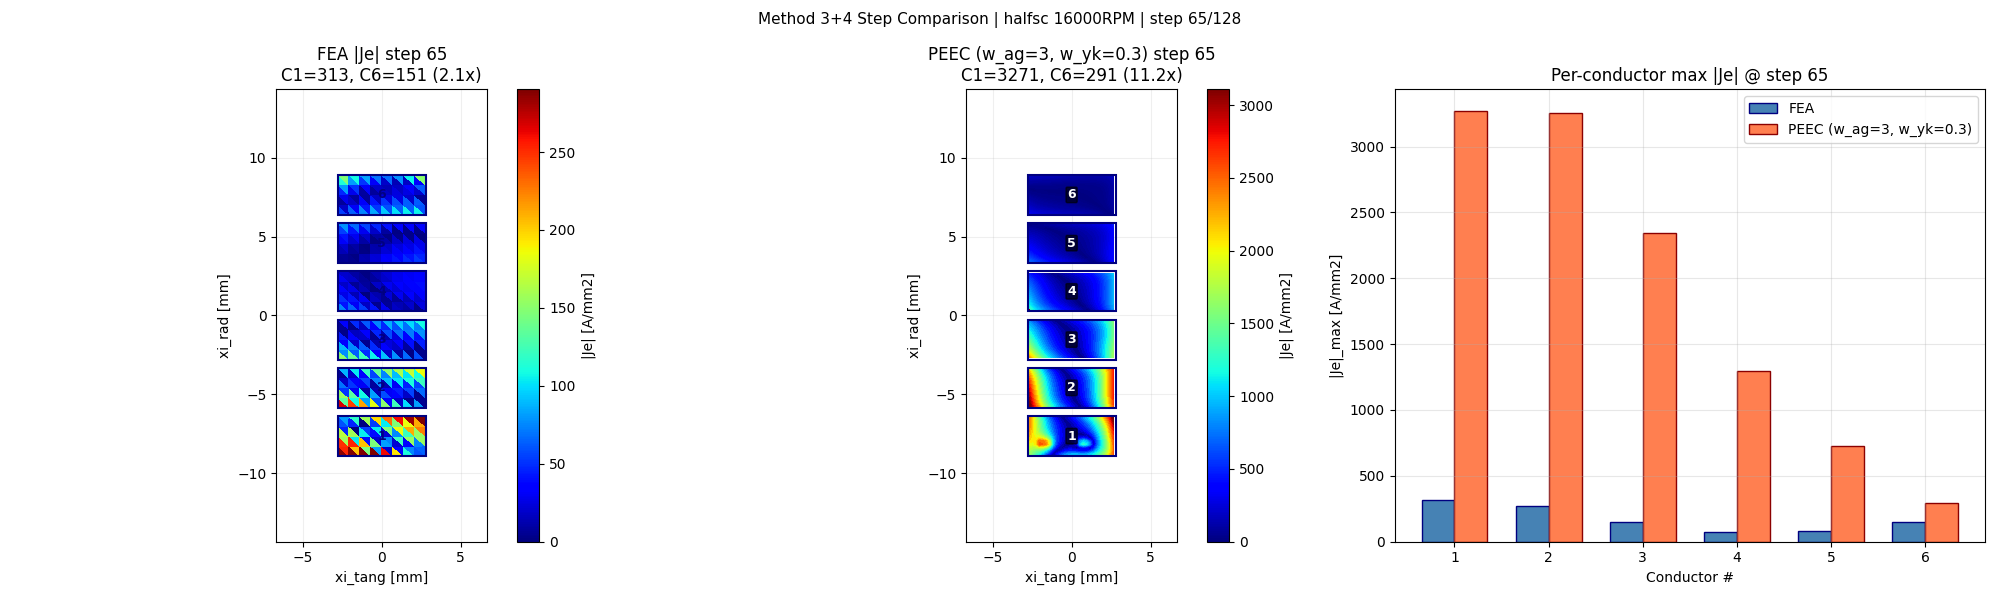

In [25]:
# ═══════════════════════════════════════════════════════════════
# [D4] Visualization: FEA vs PEEC Method 3+4 (step-selectable)
# ═══════════════════════════════════════════════════════════════
# Change PLOT_STEP to compare at different time steps.
# FEA: extracts Je at that step.  PEEC: reconstructs time-domain via IFFT.
PLOT_STEP = target_step_idx   # default: same step used in C2
BEST_WEIGHT = "w_ag=3, w_yk=0.3"  # select which weight case to plot

# ─── FEA: extract Je at PLOT_STEP (node-matched) ───
mr_plot = ts_fullfea.by_step[ts_fullfea.steps[PLOT_STEP]]
je_plot_all = np.zeros(n_elem_ff)
for reg in mr_plot._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            idx = _tri_to_idx.get((n1, n2, n3))
            if idx is not None:
                je_plot_all[idx] = getattr(el, 'je', 0) or 0
je_plot_slot = np.abs(je_plot_all[is_copper_ff][slot_cu_mask_ff])

# ─── PEEC: reconstruct time-domain at PLOT_STEP ───
w_ag, w_tw, w_yk = weight_cases[BEST_WEIGHT]
w_vec_best = np.ones(n_ext)
w_vec_best[mask_airgap] = w_ag
w_vec_best[mask_tooth]  = w_tw
w_vec_best[mask_yoke]   = w_yk
L_w_best = L_ext * w_vec_best[np.newaxis, :]

i_peec_at_step = np.zeros(n_fil_total)
i_imp_at_step = np.zeros(n_fil_total)
for nh in harmonic_indices:
    omega_n = nh * omega
    Z_n = R_matrix + 1j * omega_n * L_matrix
    Z_n_inv = inv(Z_n); ZnC = Z_n_inv @ C; CZnC = C.T @ ZnC
    V_n = 1j * omega_n * (L_w_best @ I_mag_fft_ext[nh])
    i_raw = Z_n_inv @ V_n
    i_corr = ZnC @ np_solve(CZnC, -C.T @ i_raw)
    phase = 2 * np.pi * nh * PLOT_STEP / n_steps
    if nh == 1:
        i_imp_n = ZnC @ np_solve(CZnC, I_test)
        i_total_n = i_imp_n + i_raw + i_corr
        i_peec_at_step += np.real(i_total_n * np.exp(1j * phase))
        i_imp_at_step += np.real(i_imp_n * np.exp(1j * phase))
    else:
        i_peec_at_step += np.real((i_raw + i_corr) * np.exp(1j * phase))

J_eddy_step = np.abs(i_peec_at_step - i_imp_at_step) / grid_local.area_fil * 1e-6

# ─── Per-conductor max ───
cond_fea_step = []
for ci in range(n_cond):
    in_c = all_cond_paths[slot_poly_idx[ci]].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
    cond_fea_step.append(je_plot_slot[in_c].max() if in_c.sum() > 0 else 0)

cond_peec_step = []
for ci in range(n_cond):
    fs = ci * n_fil_per
    cond_peec_step.append(J_eddy_step[fs:fs+n_fil_per].max())

print(f"Step {PLOT_STEP+1}/{n_steps_ff} | Weight: {BEST_WEIGHT}")
print(f"  FEA  C1={cond_fea_step[0]:.1f}, C6={cond_fea_step[-1]:.1f} (ratio={cond_fea_step[0]/max(cond_fea_step[-1],1e-6):.2f}x)")
print(f"  PEEC C1={cond_peec_step[0]:.1f}, C6={cond_peec_step[-1]:.1f} (ratio={cond_peec_step[0]/max(cond_peec_step[-1],1e-6):.2f}x)")
print(f"  PEEC/FEA ratio: C1={cond_peec_step[0]/max(cond_fea_step[0],1e-6):.1f}x, C6={cond_peec_step[-1]/max(cond_fea_step[-1],1e-6):.1f}x")

# ─── Slot-area axis limits (conductor extent + margin) ───
_margin_m = max(cw_m, ch_m) * 1.2
_xlim = ((cond_local_rotated[:, 0].min() - _margin_m) * 1e3,
         (cond_local_rotated[:, 0].max() + _margin_m) * 1e3)
_ylim = ((cond_local_rotated[:, 1].min() - _margin_m) * 1e3,
         (cond_local_rotated[:, 1].max() + _margin_m) * 1e3)

# ─── Plot: 개별 vmax (FEA/PEEC 스케일이 다를 수 있으므로) ───
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
w_mm_v = cw_m * 1e3; h_mm_v = ch_m * 1e3
vmax_fea = max(np.percentile(je_plot_slot, 99), 1)
vmax_peec = max(J_eddy_step.max() * 0.95, 1)

# (1) FEA |Je|
ax = axes[0]
for ci in range(n_cond):
    in_c = all_cond_paths[slot_poly_idx[ci]].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
    if in_c.sum() < 3: continue
    tri = Triangulation(node_x_local_mm, node_y_local_mm, triangles=triangles_ff[slot_cu_indices[in_c]])
    ax.tripcolor(tri, facecolors=je_plot_slot[in_c], cmap='jet', vmin=0, vmax=vmax_fea, zorder=2)
for ci in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci] * 1e3
    ax.add_patch(Rectangle((cx_l-w_mm_v/2, cy_l-h_mm_v/2), w_mm_v, h_mm_v,
                 lw=1.5, edgecolor='navy', facecolor='none', zorder=5))
    ax.text(cx_l, cy_l, str(ci+1), ha='center', va='center', fontsize=9, fontweight='bold', color='navy', zorder=6)
sm0 = plt.cm.ScalarMappable(cmap='jet', norm=Normalize(vmin=0, vmax=vmax_fea))
sm0.set_array([]); plt.colorbar(sm0, ax=ax, label='|Je| [A/mm2]')
ax.set_title(f'FEA |Je| step {PLOT_STEP+1}\nC1={cond_fea_step[0]:.0f}, C6={cond_fea_step[-1]:.0f}'
             f' ({cond_fea_step[0]/max(cond_fea_step[-1],1e-6):.1f}x)')
ax.set_aspect('equal'); ax.set_xlim(_xlim); ax.set_ylim(_ylim); ax.grid(True, alpha=0.2)
ax.set_xlabel('xi_tang [mm]'); ax.set_ylabel('xi_rad [mm]')

# (2) PEEC
ax = axes[1]
for ci in range(n_cond):
    fs = ci * n_fil_per
    J_c = J_eddy_step[fs:fs+n_fil_per].reshape(ny, nx)
    cx_p = cond_local_rotated[ci, 0] * 1e3; cy_p = cond_local_rotated[ci, 1] * 1e3
    xc = np.linspace(cx_p-w_mm_v/2+w_mm_v/(2*nx), cx_p+w_mm_v/2-w_mm_v/(2*nx), nx)
    yc = np.linspace(cy_p-h_mm_v/2+h_mm_v/(2*ny), cy_p+h_mm_v/2-h_mm_v/(2*ny), ny)
    X, Y = np.meshgrid(xc, yc)
    ax.contourf(X, Y, J_c, levels=32, cmap='jet', extend='max', vmin=0, vmax=vmax_peec, zorder=2)
for ci in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci] * 1e3
    ax.add_patch(Rectangle((cx_l-w_mm_v/2, cy_l-h_mm_v/2), w_mm_v, h_mm_v,
                 lw=1.5, edgecolor='navy', facecolor='none', zorder=5))
    ax.text(cx_l, cy_l, str(ci+1), ha='center', va='center', fontsize=9, fontweight='bold',
            color='white', zorder=6, bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.6))
sm1 = plt.cm.ScalarMappable(cmap='jet', norm=Normalize(vmin=0, vmax=vmax_peec))
sm1.set_array([]); plt.colorbar(sm1, ax=ax, label='|Je| [A/mm2]')
ax.set_title(f'PEEC ({BEST_WEIGHT}) step {PLOT_STEP+1}\nC1={cond_peec_step[0]:.0f}, C6={cond_peec_step[-1]:.0f}'
             f' ({cond_peec_step[0]/max(cond_peec_step[-1],1e-6):.1f}x)')
ax.set_aspect('equal'); ax.set_xlim(_xlim); ax.set_ylim(_ylim); ax.grid(True, alpha=0.2)
ax.set_xlabel('xi_tang [mm]'); ax.set_ylabel('xi_rad [mm]')

# (3) Bar chart
ax = axes[2]
x_bar = np.arange(1, n_cond+1)
bar_w = 0.35
ax.bar(x_bar - bar_w/2, cond_fea_step, bar_w, label='FEA', color='steelblue', edgecolor='navy')
ax.bar(x_bar + bar_w/2, cond_peec_step, bar_w, label=f'PEEC ({BEST_WEIGHT})', color='coral', edgecolor='darkred')
ax.set_xlabel('Conductor #')
ax.set_ylabel('|Je|_max [A/mm2]')
ax.set_title(f'Per-conductor max |Je| @ step {PLOT_STEP+1}')
ax.set_xticks(x_bar)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Method 3+4 Step Comparison | {TARGET_MODEL} {TARGET_SPEED}RPM | step {PLOT_STEP+1}/{n_steps_ff}',
             fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# [D5] Interactive Step Comparison: FEA vs PEEC (ipywidgets)
# ═══════════════════════════════════════════════════════════════
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display as ipy_display

# ─── Slot-area axis limits (도체 범위 + 여유) ───
_margin_m = max(cw_m, ch_m) * 1.2
_xlim_slot = ((cond_local_rotated[:, 0].min() - _margin_m) * 1e3,
              (cond_local_rotated[:, 0].max() + _margin_m) * 1e3)
_ylim_slot = ((cond_local_rotated[:, 1].min() - _margin_m) * 1e3,
              (cond_local_rotated[:, 1].max() + _margin_m) * 1e3)

# ─── Precompute PEEC harmonic phasors (Method 3+4, best weight) ───
BEST_WEIGHT_INT = "w_ag=3, w_yk=0.3"
w_ag_i, w_tw_i, w_yk_i = weight_cases[BEST_WEIGHT_INT]
w_vec_i = np.ones(n_ext)
w_vec_i[mask_airgap] = w_ag_i
w_vec_i[mask_tooth]  = w_tw_i
w_vec_i[mask_yoke]   = w_yk_i
L_w_int = L_ext * w_vec_i[np.newaxis, :]

peec_phasors = {}
peec_imp_phasor = None
for nh in harmonic_indices:
    omega_n = nh * omega
    Z_n = R_matrix + 1j * omega_n * L_matrix
    Z_n_inv = inv(Z_n); ZnC = Z_n_inv @ C; CZnC = C.T @ ZnC
    V_n = 1j * omega_n * (L_w_int @ I_mag_fft_ext[nh])
    i_raw = Z_n_inv @ V_n
    i_corr = ZnC @ np_solve(CZnC, -C.T @ i_raw)
    if nh == 1:
        peec_imp_phasor = ZnC @ np_solve(CZnC, I_test)
        peec_phasors[nh] = peec_imp_phasor + i_raw + i_corr
    else:
        peec_phasors[nh] = i_raw + i_corr

print(f"Phasors precomputed: {len(peec_phasors)} harmonics | {BEST_WEIGHT_INT}")


def reconstruct_peec_step(step_idx):
    """Reconstruct PEEC time-domain filament eddy current density at a given step."""
    i_total = np.zeros(n_fil_total)
    i_imp = np.zeros(n_fil_total)
    for nh, i_n in peec_phasors.items():
        phase = 2 * np.pi * nh * step_idx / n_steps
        i_total += np.real(i_n * np.exp(1j * phase))
        if nh == 1:
            i_imp += np.real(peec_imp_phasor * np.exp(1j * phase))
    # 부호 있는 와전류 밀도 [A/mm²]
    return (i_total - i_imp) / grid_local.area_fil * 1e-6


def extract_fea_step(step_idx):
    """Extract FEA Je (signed) for slot copper at given step (node-matched)."""
    mr_s = ts_fullfea.by_step[ts_fullfea.steps[step_idx]]
    je_arr = np.zeros(n_elem_ff)
    for reg in mr_s._regions:
        for el in reg.elements:
            n1 = node_id_to_idx_ff.get(el.node_1, -1)
            n2 = node_id_to_idx_ff.get(el.node_2, -1)
            n3 = node_id_to_idx_ff.get(el.node_3, -1)
            if n1 >= 0 and n2 >= 0 and n3 >= 0:
                idx = _tri_to_idx.get((n1, n2, n3))
                if idx is not None:
                    je_arr[idx] = getattr(el, 'je', 0) or 0
    # 부호 유지 (절대값 제거)
    return je_arr[is_copper_ff][slot_cu_mask_ff]


# ─── Interactive widget ───
step_slider = widgets.IntSlider(
    value=target_step_idx, min=0, max=n_steps_ff-1, step=1,
    description='Step:', continuous_update=False,
    layout=widgets.Layout(width='600px')
)
weight_dd = widgets.Dropdown(
    options=list(weight_cases.keys()),
    value=BEST_WEIGHT_INT,
    description='Weight:'
)
out_plot = widgets.Output()

_fig_state = {"fig": None}

def _update_plot(change=None):
    si = step_slider.value
    
    je_fea_s = extract_fea_step(si)          # signed Je [A/mm²]
    J_peec_s = reconstruct_peec_step(si)     # signed Je [A/mm²]
    
    # Per-conductor stats (|max| 기준)
    fea_cond_abs = []
    for ci in range(n_cond):
        in_c = all_cond_paths[slot_poly_idx[ci]].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
        fea_cond_abs.append(np.abs(je_fea_s[in_c]).max() if in_c.sum() > 0 else 0)
    peec_cond_abs = [np.abs(J_peec_s[ci*n_fil_per:(ci+1)*n_fil_per]).max() for ci in range(n_cond)]
    
    # 대칭 colorbar (signed 표현)
    vmax_fea = max(np.percentile(np.abs(je_fea_s), 99) if je_fea_s.size > 0 else 1, 1)
    vmax_peec_abs = max(np.abs(J_peec_s).max() * 0.95, 1)
    
    with out_plot:
        out_plot.clear_output(wait=True)
        
        if _fig_state["fig"] is not None:
            plt.close(_fig_state["fig"])
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
        _fig_state["fig"] = fig
        
        # (1) FEA Je (signed, RdBu_r)
        ax = axes[0]
        for ci in range(n_cond):
            in_c = all_cond_paths[slot_poly_idx[ci]].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
            if in_c.sum() < 3: continue
            tri = Triangulation(node_x_local_mm, node_y_local_mm, triangles=triangles_ff[slot_cu_indices[in_c]])
            ax.tripcolor(tri, facecolors=je_fea_s[in_c],
                         cmap='RdBu_r', vmin=-vmax_fea, vmax=vmax_fea, zorder=2)
        for ci in range(n_cond):
            cx_l, cy_l = cond_local_rotated[ci] * 1e3
            ax.add_patch(Rectangle((cx_l-cw_m*500, cy_l-ch_m*500), cw_m*1e3, ch_m*1e3,
                         lw=1, edgecolor='k', facecolor='none', zorder=5))
            ax.text(cx_l, cy_l, str(ci+1), ha='center', va='center', fontsize=8,
                    color='black', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6))
        sm0 = plt.cm.ScalarMappable(cmap='RdBu_r', norm=Normalize(vmin=-vmax_fea, vmax=vmax_fea))
        sm0.set_array([]); fig.colorbar(sm0, ax=ax, label='Je [A/mm²]', shrink=0.8)
        ax.set_title(f'FEA Je (signed) step {si+1}\n'
                     f'C1={fea_cond_abs[0]:.0f} C6={fea_cond_abs[-1]:.0f} '
                     f'({fea_cond_abs[0]/max(fea_cond_abs[-1],1e-6):.1f}x)')
        ax.set_aspect('equal'); ax.set_xlim(_xlim_slot); ax.set_ylim(_ylim_slot); ax.grid(True, alpha=0.2)
        ax.set_xlabel('tang [mm]'); ax.set_ylabel('rad [mm]')
        
        # (2) PEEC Je (signed, RdBu_r)
        ax = axes[1]
        for ci in range(n_cond):
            fs = ci * n_fil_per
            J_c = J_peec_s[fs:fs+n_fil_per].reshape(ny, nx)
            cx_p = cond_local_rotated[ci, 0] * 1e3; cy_p = cond_local_rotated[ci, 1] * 1e3
            xc = np.linspace(cx_p-cw_m*500+cw_m*1e3/(2*nx), cx_p+cw_m*500-cw_m*1e3/(2*nx), nx)
            yc = np.linspace(cy_p-ch_m*500+ch_m*1e3/(2*ny), cy_p+ch_m*500-ch_m*1e3/(2*ny), ny)
            X, Y = np.meshgrid(xc, yc)
            ax.contourf(X, Y, J_c, levels=32, cmap='RdBu_r', extend='both',
                        vmin=-vmax_peec_abs, vmax=vmax_peec_abs, zorder=2)
        for ci in range(n_cond):
            cx_l, cy_l = cond_local_rotated[ci] * 1e3
            ax.add_patch(Rectangle((cx_l-cw_m*500, cy_l-ch_m*500), cw_m*1e3, ch_m*1e3,
                         lw=1, edgecolor='k', facecolor='none', zorder=5))
            ax.text(cx_l, cy_l, str(ci+1), ha='center', va='center', fontsize=8,
                    color='black', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6))
        sm1 = plt.cm.ScalarMappable(cmap='RdBu_r', norm=Normalize(vmin=-vmax_peec_abs, vmax=vmax_peec_abs))
        sm1.set_array([]); fig.colorbar(sm1, ax=ax, label='Je [A/mm²]', shrink=0.8)
        ax.set_title(f'PEEC ({BEST_WEIGHT_INT}) Je (signed) step {si+1}\n'
                     f'C1={peec_cond_abs[0]:.0f} C6={peec_cond_abs[-1]:.0f} '
                     f'({peec_cond_abs[0]/max(peec_cond_abs[-1],1e-6):.1f}x)')
        ax.set_aspect('equal'); ax.set_xlim(_xlim_slot); ax.set_ylim(_ylim_slot); ax.grid(True, alpha=0.2)
        ax.set_xlabel('tang [mm]'); ax.set_ylabel('rad [mm]')
        
        # (3) Bar chart (|max| 기준)
        ax = axes[2]
        x_b = np.arange(1, n_cond+1)
        bw = 0.35
        ax.bar(x_b - bw/2, fea_cond_abs, bw, label='FEA |Je|_max', color='steelblue', edgecolor='navy')
        ax.bar(x_b + bw/2, peec_cond_abs, bw, label='PEEC |Je|_max', color='coral', edgecolor='darkred')
        ax.set_xlabel('Cond #'); ax.set_ylabel('|Je|_max [A/mm²]')
        ax.set_title(f'Step {si+1}/{n_steps_ff}  (PEEC/FEA={peec_cond_abs[0]/max(fea_cond_abs[0],1e-6):.1f}x)')
        ax.set_xticks(x_b); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        
        fig.suptitle(f'{TARGET_MODEL} {TARGET_SPEED}RPM | Method 3+4 | step {si+1}/{n_steps_ff}', fontsize=11)
        fig.tight_layout()
        plt.show()

step_slider.observe(_update_plot, names='value')

ipy_display(widgets.VBox([
    widgets.HBox([step_slider, weight_dd]),
    out_plot
]))
_update_plot()